# Top merge diagnostic (Layer 2b): Identify merge-causing edges and estimate damage

This notebook takes the per-mention `decisions_<split>.jsonl` (from `eval_signature_antecedent_v2.py --save_decisions`)
and reconstructs the incremental union-find clustering **in mention order**.

We record a **merge event** whenever a chosen antecedent link `i -> j` merges two previously separate predicted components.

For each merge event we compute "damage" proxies:
- `size_after`: number of processed mentions in the merged component after the union
- `n_gold_after`: number of distinct gold clusters inside that component after the union
- `impurity_increase`: `n_gold_after - max(n_gold_left, n_gold_right)` (how many new gold clusters are introduced by this union)

The highest-impact failures typically are:
- large `size_after`
- large `n_gold_after`
- large `impurity_increase`
especially when the edge is a **wrong-link** (gold_cluster[i] != gold_cluster[j]).


In [28]:
import json
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [29]:
# ----------------
# CONFIG (edit me)
# ----------------
DECISIONS_JSONL = Path("eval_outputs/analysis/scibert/16_hybrid_24_48_384/epoch3/decisions_validation.jsonl")  # <-- change
TOPK = 50

assert DECISIONS_JSONL.exists(), f"Missing: {DECISIONS_JSONL}"


In [30]:
# Load decisions
rows=[]
with DECISIONS_JSONL.open("r", encoding="utf-8") as f:
    for line in f:
        if not line.strip():
            continue
        rows.append(json.loads(line))
df = pd.DataFrame(rows)

# ensure correct dtypes
for c in ["topic_id","mention_idx","chosen_antecedent","gold_cluster"]:
    df[c] = pd.to_numeric(df[c], errors="coerce").astype("Int64")

df["chosen_antecedent"] = df["chosen_antecedent"].fillna(-1).astype(int)
df["topic_id"] = df["topic_id"].astype(int)
df["mention_idx"] = df["mention_idx"].astype(int)
df["gold_cluster"] = df["gold_cluster"].astype(int)

print("rows:", len(df), "topics:", df["topic_id"].nunique())
df.head()


rows: 4873 topics: 100


,split,topic_id,mention_idx,pid,start,end,gold_cluster,pred_cluster,has_gold_antecedent,gold_present,...,error_type,match_kind,match_kind_raw,used_extended_context,fallback_reason,sig_type,sig_n_aliases,sig_n_out,sig_n_in,sig_len_chars
0,validation,742,0,0,34,35,4,0,False,False,...,new_correct,rel,rel,False,,method,0,0,0,0
1,validation,742,1,1,20,22,11,0,False,False,...,new_wrong_link,rel,rel,False,,task,0,0,1,0
2,validation,742,2,2,32,33,4,0,True,True,...,correct_link,wd,wd,False,,task,0,2,1,0
3,validation,742,3,3,54,55,0,1,False,False,...,new_correct,wd,wd,False,,method,0,0,0,0
4,validation,742,4,4,11,13,0,1,True,True,...,correct_link,wd,wd,False,,method,0,1,1,0


In [31]:
# Union-Find for incremental clustering over processed mentions only

class UF:
    def __init__(self, n):
        self.parent = list(range(n))
        self.rank = [0]*n
    def find(self, x):
        while self.parent[x] != x:
            self.parent[x] = self.parent[self.parent[x]]
            x = self.parent[x]
        return x
    def union(self, a, b):
        ra, rb = self.find(a), self.find(b)
        if ra == rb:
            return ra, rb, ra, False
        if self.rank[ra] < self.rank[rb]:
            self.parent[ra] = rb
            return ra, rb, rb, True
        elif self.rank[ra] > self.rank[rb]:
            self.parent[rb] = ra
            return ra, rb, ra, True
        else:
            self.parent[rb] = ra
            self.rank[ra] += 1
            return ra, rb, ra, True

def merge_events_for_topic(df_topic: pd.DataFrame):
    df_topic = df_topic.sort_values("mention_idx")
    n = int(df_topic["mention_idx"].max()) + 1

    uf = UF(n)

    # processed-only component stats
    active = [False]*n
    comp_size = defaultdict(int)   # root -> #processed mentions
    comp_gold = defaultdict(set)   # root -> set(gold_cluster_ids among processed mentions)

    events = []

    # helper to ensure stats exist for current root
    def _touch(root):
        if root not in comp_size:
            comp_size[root] = 0
        if root not in comp_gold:
            comp_gold[root] = set()

    # index rows for quick access
    gold_by_i = dict(zip(df_topic["mention_idx"].tolist(), df_topic["gold_cluster"].tolist()))
    row_by_i = {int(r["mention_idx"]): r for r in df_topic.to_dict("records")}

    for i in range(n):
        if i not in row_by_i:
            # should not happen if decisions cover all mentions, but be safe
            continue

        # activate mention i
        if not active[i]:
            active[i] = True
            ri = uf.find(i)
            _touch(ri)
            comp_size[ri] += 1
            comp_gold[ri].add(int(gold_by_i[i]))

        chosen = int(row_by_i[i].get("chosen_antecedent", -1))
        if chosen == -1:
            continue

        # chosen is always < i in your decoding; but be defensive
        if chosen < 0 or chosen >= n:
            continue

        # ensure chosen is activated (it should be, since chosen < i)
        if not active[chosen]:
            active[chosen] = True
            rj = uf.find(chosen)
            _touch(rj)
            comp_size[rj] += 1
            comp_gold[rj].add(int(gold_by_i[chosen]))

        ri = uf.find(i)
        rj = uf.find(chosen)
        if ri == rj:
            continue  # no merge event

        # stats before
        size_i = comp_size[ri]
        size_j = comp_size[rj]
        gold_i = set(comp_gold[ri])
        gold_j = set(comp_gold[rj])

        ra, rb, rnew, merged = uf.union(i, chosen)
        if not merged:
            continue

        # recompute roots after union
        rnew = uf.find(i)
        rold_i = uf.find(ra)  # may now point to rnew
        rold_j = uf.find(rb)

        # new stats: union of processed-only stats
        # Need to gather pre-union stats using ra/rb (the roots before union)
        # We stored them as ri/rj.
        new_size = size_i + size_j
        new_gold = gold_i.union(gold_j)

        # update root stats: clear old roots, assign to new root
        # Determine which root survived (rnew)
        comp_size[rnew] = new_size
        comp_gold[rnew] = new_gold
        # old roots may still exist as keys; leave them but they won't be used because find() changes.

        n_gold_i = len(gold_i)
        n_gold_j = len(gold_j)
        n_gold_new = len(new_gold)
        impurity_increase = n_gold_new - max(n_gold_i, n_gold_j)

        # edge correctness
        gold_ci = int(gold_by_i[i])
        gold_cj = int(gold_by_i[chosen])
        edge_wrong = int(gold_ci != gold_cj)

        # attach confidence fields if present
        best_logit = row_by_i[i].get("best_logit", None)
        eps_logit = row_by_i[i].get("eps_logit", None)
        margin = row_by_i[i].get("margin_best_vs_2nd", None)

        events.append({
            "mention_idx": i,
            "chosen_antecedent": chosen,
            "edge_wrong": edge_wrong,
            "gold_i": gold_ci,
            "gold_j": gold_cj,
            "size_left": size_i,
            "size_right": size_j,
            "size_after": new_size,
            "n_gold_left": n_gold_i,
            "n_gold_right": n_gold_j,
            "n_gold_after": n_gold_new,
            "impurity_increase": impurity_increase,
            "best_logit": best_logit,
            "eps_logit": eps_logit,
            "margin_best_vs_2nd": margin,
        })

    return pd.DataFrame(events)

# run for all topics
events_all = []
for tid, dft in df.groupby("topic_id"):
    ev = merge_events_for_topic(dft)
    if len(ev):
        ev.insert(0, "topic_id", tid)
        events_all.append(ev)

events = pd.concat(events_all, ignore_index=True) if events_all else pd.DataFrame()
print("merge events:", len(events))
events.head()


merge events: 3136


,topic_id,mention_idx,chosen_antecedent,edge_wrong,gold_i,gold_j,size_left,size_right,size_after,n_gold_left,n_gold_right,n_gold_after,impurity_increase,best_logit,eps_logit,margin_best_vs_2nd
0,742,1,0,1,11,4,1,1,2,1,1,2,1,5.084636,0.000603,5.084033
1,742,2,0,0,4,4,1,2,3,1,2,2,0,5.195340,0.000603,0.781216
2,742,4,3,0,0,0,1,1,2,1,1,1,0,5.007370,0.000603,5.006767
3,742,5,4,0,0,0,1,2,3,1,1,1,0,5.264301,0.000603,0.057790
4,742,7,6,0,5,5,1,1,2,1,1,1,0,5.211877,0.000603,5.211274


In [37]:
# Define a 'damage' score to rank events.
# There is no single correct metric. This one emphasizes big + impure merges.
if len(events):
    events["damage"] = events["size_after"] * (events["n_gold_after"] - 1)
    # also helpful: whether this merge introduces impurity from a pure state
    events["introduces_impurity"] = ((events["n_gold_left"] == 1) & (events["n_gold_right"] == 1) & (events["n_gold_after"] > 1)).astype(int)

    # show top events by damage
    top = events.sort_values(["damage","impurity_increase","size_after"], ascending=False).head(20)
    display(top)
else:
    print("No merge events found (unexpected if you have links).")


,topic_id,mention_idx,chosen_antecedent,edge_wrong,gold_i,gold_j,size_left,size_right,size_after,n_gold_left,n_gold_right,n_gold_after,impurity_increase,best_logit,eps_logit,margin_best_vs_2nd,damage,introduces_impurity
2501,821,69,19,1,24,14,1,23,24,1,6,7,1,1.055294,0.000603,0.718770,144,0
2034,805,34,23,0,6,6,1,22,23,1,7,7,0,5.212226,0.000603,0.013909,138,0
2032,805,32,23,0,6,6,1,21,22,1,7,7,0,5.135475,0.000603,0.023700,132,0
2949,836,47,45,0,6,6,1,25,26,1,6,6,0,5.237606,0.000603,0.061438,130,0
2031,805,31,23,1,7,6,1,20,21,1,6,7,1,1.445454,0.000603,0.271973,126,0
2948,836,46,45,0,6,6,1,24,25,1,6,6,0,4.857259,0.000603,0.052224,125,0
2947,836,45,44,0,6,6,1,23,24,1,6,6,0,5.203355,0.000603,0.181666,120,0
2500,821,68,12,0,14,14,1,22,23,1,6,6,0,0.592656,0.000603,0.592053,115,0
2946,836,44,39,0,6,6,1,22,23,1,6,6,0,3.063279,0.000603,0.375224,115,0
675,764,23,18,1,2,4,1,21,22,1,5,6,1,2.353124,0.000603,2.352521,110,0


In [38]:
first_bad = (events[(events["edge_wrong"]==1) & (events["introduces_impurity"]==1)]
             .sort_values(["topic_id","mention_idx"])
             .groupby("topic_id").head(1))
first_bad.sort_values("damage", ascending=False).head(50)

,topic_id,mention_idx,chosen_antecedent,edge_wrong,gold_i,gold_j,size_left,size_right,size_after,n_gold_left,n_gold_right,n_gold_after,impurity_increase,best_logit,eps_logit,margin_best_vs_2nd,damage,introduces_impurity
1962,803,33,29,1,5,6,1,25,26,1,1,2,1,4.967313,0.000603,0.689315,26,1
1242,782,17,14,1,0,12,1,16,17,1,1,2,1,3.726403,0.000603,1.084734,17,1
2576,824,54,53,1,8,5,1,15,16,1,1,2,1,4.634831,0.000603,1.722650,16,1
531,759,21,12,1,8,5,1,14,15,1,1,2,1,4.666814,0.000603,1.231920,15,1
847,770,14,1,1,3,0,1,13,14,1,1,2,1,1.115381,0.000603,1.114778,14,1
561,761,11,9,1,0,6,1,11,12,1,1,2,1,0.674082,0.000603,0.330502,12,1
776,768,16,5,1,6,2,1,11,12,1,1,2,1,4.004614,0.000603,0.985149,12,1
1351,786,19,12,1,3,5,1,10,11,1,1,2,1,1.438880,0.000603,0.091622,11,1
2720,829,30,9,1,4,0,1,10,11,1,1,2,1,2.671782,0.000603,0.230746,11,1
495,758,9,4,1,8,7,1,9,10,1,1,2,1,0.278127,0.000603,0.277524,10,1


fraction merge events with edge_wrong=1: 0.16358418367346939
fraction merge events that introduce impurity: 0.08003826530612244


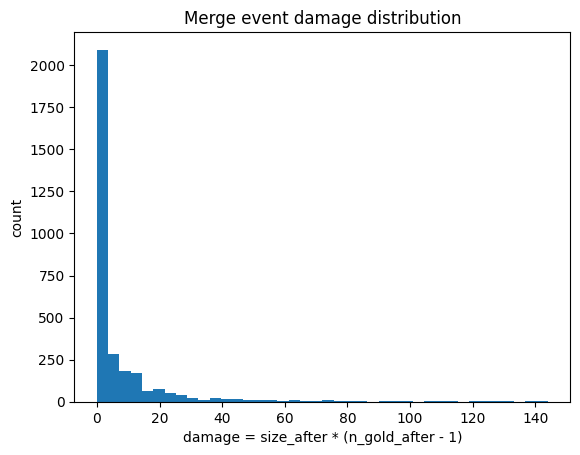

In [33]:
# Summary: how many merge events are wrong-link edges?
if len(events):
    print("fraction merge events with edge_wrong=1:", (events["edge_wrong"]==1).mean())
    print("fraction merge events that introduce impurity:", events["introduces_impurity"].mean())

    plt.figure()
    plt.hist(events["damage"], bins=40)
    plt.title("Merge event damage distribution")
    plt.xlabel("damage = size_after * (n_gold_after - 1)")
    plt.ylabel("count")
    plt.show()


In [34]:
# Worst topics by max merge damage
if len(events):
    by_topic = events.groupby("topic_id").agg(
        n_events=("damage","size"),
        max_damage=("damage","max"),
        max_n_gold=("n_gold_after","max"),
        max_size=("size_after","max"),
        frac_wrong=("edge_wrong","mean"),
    ).reset_index().sort_values("max_damage", ascending=False)

    display(by_topic.head(30))


,topic_id,n_events,max_damage,max_n_gold,max_size,frac_wrong
79,821,50,144,7,24,0.240000
63,805,34,138,7,23,0.235294
94,836,43,130,6,26,0.162791
22,764,26,110,6,22,0.269231
45,787,41,108,7,18,0.390244
13,755,39,80,6,16,0.564103
41,783,22,77,8,11,0.409091
40,782,36,72,5,19,0.194444
34,776,40,72,4,24,0.125000
46,788,73,68,3,34,0.219178


In [35]:
# Optional: show top events with signature meta columns if present in decisions
# (Only works if your decisions JSONL includes match_kind/sig_type/etc for the CURRENT mention.)
cols = ["topic_id","mention_idx","chosen_antecedent","edge_wrong","gold_i","gold_j","size_after","n_gold_after","impurity_increase","damage",
        "best_logit","eps_logit","margin_best_vs_2nd","introduces_impurity"]
extra = [c for c in ["match_kind","sig_type","sig_n_out","sig_n_in","sig_n_aliases","used_extended_context","fallback_reason"] if c in df.columns]
print("extra cols available:", extra)

if len(events):
    top = events.sort_values(["damage","impurity_increase","size_after"], ascending=False).head(TOPK)
    # join extra info for the *current* mention_idx in each event
    df_key = df[["topic_id","mention_idx"] + extra].drop_duplicates()
    top2 = top.merge(df_key, on=["topic_id","mention_idx"], how="left")
    display(top2[cols + extra].head(TOPK))


extra cols available: ['match_kind', 'sig_type', 'sig_n_out', 'sig_n_in', 'sig_n_aliases', 'used_extended_context', 'fallback_reason']


,topic_id,mention_idx,chosen_antecedent,edge_wrong,gold_i,gold_j,size_after,n_gold_after,impurity_increase,damage,...,eps_logit,margin_best_vs_2nd,introduces_impurity,match_kind,sig_type,sig_n_out,sig_n_in,sig_n_aliases,used_extended_context,fallback_reason
0,821,69,19,1,24,14,24,7,1,144,...,0.000603,0.718770,0,rel,other scientific term,2,1,0,False,
1,805,34,23,0,6,6,23,7,0,138,...,0.000603,0.013909,0,rel,task,0,2,0,False,
2,805,32,23,0,6,6,22,7,0,132,...,0.000603,0.023700,0,rel,task,0,0,0,False,
3,836,47,45,0,6,6,26,6,0,130,...,0.000603,0.061438,0,rel,method,1,1,0,False,
4,805,31,23,1,7,6,21,7,1,126,...,0.000603,0.271973,0,rel,task,1,1,0,False,
5,836,46,45,0,6,6,25,6,0,125,...,0.000603,0.052224,0,rel,metric,1,0,0,False,
6,836,45,44,0,6,6,24,6,0,120,...,0.000603,0.181666,0,rel,metric,2,0,0,False,
7,821,68,12,0,14,14,23,6,0,115,...,0.000603,0.592053,0,rel,method,0,1,0,False,
8,836,44,39,0,6,6,23,6,0,115,...,0.000603,0.375224,0,none,unknown,0,0,0,True,no_match
9,764,23,18,1,2,4,22,6,1,110,...,0.000603,2.352521,0,none,unknown,0,0,0,True,no_match
